In [1]:
import os
import gc

os.chdir('../../')

In [2]:
import mlflow
import pandas as pd
import numpy as np
import catboost as cb
import json
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from boruta import BorutaPy
from sklearn.ensemble import RandomForestRegressor

# For MAPIE Conformal
from mapie.metrics import (regression_coverage_score,
                           regression_mean_width_score)

from sklearn.metrics import mean_squared_error

/Users/henriquecosta/workspace/studies/modern-ml/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
mlflow.set_experiment('final_quantile_model')

2025/02/12 12:55:55 INFO mlflow.tracking.fluent: Experiment with name 'final_quantile_model' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///Users/henriquecosta/workspace/studies/modern-ml/mlruns/671055360367888894', creation_time=1739375755149, experiment_id='671055360367888894', last_update_time=1739375755149, lifecycle_stage='active', name='final_quantile_model', tags={}>

In [4]:
def plot_prediction_vs_actual(run_name, y_val, median, lower_bound, upper_bound):
    plt.figure(figsize=(10,5))
    result_df = pd.DataFrame({
        "y_val": y_val,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "median_pred": median
    })
    sns.scatterplot(x='median_pred', y='y_val', data=result_df, marker='o', linestyle='', alpha=0.9)
    plt.errorbar(result_df['median_pred'], result_df['y_val'], 
                 yerr=(result_df['upper_bound'] - result_df['lower_bound']), fmt='o', color='blue', alpha=0.7, ecolor='gray', elinewidth=1, capsize=3)
    plt.legend()
    plt.title(run_name)
    plt.xlabel("Predicted Price")
    plt.ylabel("True Price")
    plt.savefig("actua_price_versus_predicted_price.png", bbox_inches='tight')
    mlflow.log_artifact("actua_price_versus_predicted_price.png")
    plt.show()

def log_metrics(run_name, y_val, median, lower_bound, upper_bound):
    # Compute metrics
    rmse = np.sqrt(mean_squared_error(y_val, median))
    coverage = regression_coverage_score(y_val, lower_bound, upper_bound)
    width = regression_mean_width_score(lower_bound, upper_bound)

    # Log metrics
    print('Logging metrics to MLflow: ', run_name, ' ....')
    mlflow.log_param("quantile_levels", quantile_levels)
    mlflow.log_metric("rmse", rmse)
    
    mlflow.log_metric("mape", np.mean(np.abs((y_val - median) / y_val)) * 100)
    mlflow.log_metric("mae", np.mean(np.abs(y_val - median)))
    mlflow.log_metric("mdape", np.median(np.abs((y_val - median) / y_val)) * 100)

    mlflow.log_metric("coverage", coverage)
    mlflow.log_metric("interval_width", width)
    
    

    # Print metrics
    print(run_name)
    print("quantile_levels", quantile_levels)
    print("RMSE:", rmse)
    print("MAPE:", np.mean(np.abs((y_val - median) / y_val)) * 100)
    print("MAE:", np.mean(np.abs(y_val - median)))
    print("MDAPE:", np.median(np.abs((y_val - median) / y_val)) * 100)
    print("Coverage:", coverage)
    print("Interval Width:", width)

In [5]:
# Load data week_2/data/processed/sg-resale-flat-prices-engineered.parquet
df = pd.read_parquet('week_2/data/processed/sg-resale-flat-prices-engineered.parquet')

# Load features list
with open('week_2/data/processed/features_list.json', 'r') as f:
    features_list = json.load(f)

In [13]:
selected_features = [
    'floor_area_sqm',
    'remaining_lease_years',
    'lease_age',
    'prior_1_town_std_price_per_sqm',
    'prior_3_town_max_price_per_sqm',
    'prior_6_town_max_price_per_sqm',
    'prior_1_town_street_mean_price_per_sqm',
    'prior_1_town_street_max_price_per_sqm',
    'prior_3_town_street_mean_price_per_sqm',
    'prior_3_town_street_max_price_per_sqm',
    'prior_3_town_street_min_price_per_sqm',
    'prior_6_town_street_mean_price_per_sqm',
    'prior_6_town_street_max_price_per_sqm',
    'prior_6_town_street_min_price_per_sqm',
    'prior_1_town_street_block_mean_price_per_sqm',
    'prior_1_town_street_block_max_price_per_sqm',
    'prior_1_town_street_block_min_price_per_sqm',
    'prior_3_town_street_block_mean_price_per_sqm',
    'prior_3_town_street_block_max_price_per_sqm',
    'prior_6_town_street_block_mean_price_per_sqm',
    'prior_6_town_street_block_max_price_per_sqm',
    'town', 
    'flat_type', 
    'storey_range', 
    'flat_model'
]

len(selected_features) / len(features_list)

0.46296296296296297

In [14]:
split_date_train_end = pd.to_datetime("2024-01-01")
split_date_val_cal = pd.to_datetime("2024-07-01")

train_mask = (df['month'] < split_date_train_end)
val_cal_mask = (df['month'] >= split_date_train_end) & (df['month'] < split_date_val_cal)

df_train = df.loc[train_mask].copy()
df_val_cal = df.loc[val_cal_mask].copy()

# Now we split df_val_cal 50/50 with random split

np.random.seed(42)
mask = np.random.rand(len(df_val_cal)) < 0.5
df_val = df_val_cal[mask].copy()
df_cal = df_val_cal[~mask].copy()


print("Training set size:", df_train.shape)
print("Validation set size:", df_val.shape)
print("Calibration set size:", df_cal.shape)

# Features (X) and target (y) - We'll use 'corrected_price' as target
X_train = df_train[selected_features].copy()
y_train = df_train['corrected_price'].copy()

X_val = df_val[selected_features].copy()
y_val = df_val['resale_price'].copy()

X_cal = df_cal[selected_features].copy()
y_cal = df_cal['resale_price'].copy()

Training set size: (104896, 68)
Validation set size: (6119, 68)
Calibration set size: (5991, 68)


In [16]:
# Select cat features with dtype category
cat_features = X_train.select_dtypes(include=['category']).columns.tolist()
cat_features

['town', 'flat_type', 'storey_range', 'flat_model']

In [17]:
quantile_levels = [0.1, 0.5, 0.9]
quantile_str = str(quantile_levels).replace('[','').replace(']','')
quantile_str

'0.1, 0.5, 0.9'

In [18]:
df_train['corrected_price_per_sqm'] = df_train['corrected_price'] / df_train['floor_area_sqm']
df_train['log_corrected_price_per_sqm'] = np.log(df_train['corrected_price_per_sqm'])

y_train = df_train['log_corrected_price_per_sqm'].copy()

Running: Ref.: CatBoost MultiQuantile
Training the model
0:	learn: 0.0517336	total: 125ms	remaining: 2m 4s
1:	learn: 0.0512676	total: 189ms	remaining: 1m 34s
2:	learn: 0.0508032	total: 256ms	remaining: 1m 24s
3:	learn: 0.0503380	total: 317ms	remaining: 1m 18s
4:	learn: 0.0498799	total: 378ms	remaining: 1m 15s
5:	learn: 0.0494335	total: 438ms	remaining: 1m 12s
6:	learn: 0.0489960	total: 495ms	remaining: 1m 10s
7:	learn: 0.0485640	total: 548ms	remaining: 1m 7s
8:	learn: 0.0481340	total: 616ms	remaining: 1m 7s
9:	learn: 0.0477036	total: 693ms	remaining: 1m 8s
10:	learn: 0.0472816	total: 753ms	remaining: 1m 7s
11:	learn: 0.0468581	total: 809ms	remaining: 1m 6s
12:	learn: 0.0464423	total: 869ms	remaining: 1m 5s
13:	learn: 0.0460267	total: 922ms	remaining: 1m 4s
14:	learn: 0.0456216	total: 976ms	remaining: 1m 4s
15:	learn: 0.0452339	total: 1.03s	remaining: 1m 3s
16:	learn: 0.0448381	total: 1.08s	remaining: 1m 2s
17:	learn: 0.0444425	total: 1.16s	remaining: 1m 3s
18:	learn: 0.0440581	total: 1

/Users/henriquecosta/workspace/studies/modern-ml/.venv/lib/python3.11/site-packages/mapie/utils.py:620: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(
/var/folders/mc/j147q69d6p7f7t0bjfzgvbs00000gp/T/ipykernel_62667/2069095545.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


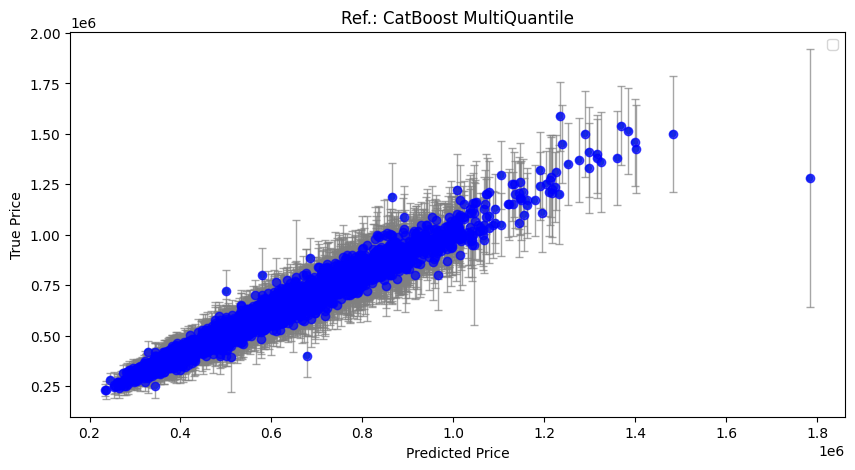

In [19]:
run_name = "Ref.: CatBoost MultiQuantile"
with mlflow.start_run(run_name=run_name):
    print(f'Running: {run_name}')

    params = dict(
        colsample_bylevel=0.7,
        depth=8,
        l2_leaf_reg=11,
        learning_rate=0.010874961110730146,
        subsample=0.8
    )

    # Initialize the CatBoostRegressor for multi-quantile
    model = cb.CatBoostRegressor(
        loss_function=f"MultiQuantile:alpha={quantile_str}",
        cat_features=cat_features,
        **params
    )
    
    # Fit the model
    print('Training the model')
    model.fit(X_train, y_train)

    # Predict on validation
    predictions = model.predict(X_val)
    predictions = np.exp(predictions)
    predictions *= X_val['floor_area_sqm'].values[:, None]
    
    lower_bound = predictions[:, 0] # predictions[:, 0] -> lower 10%
    median_pred = predictions[:, 1] # predictions[:, 1] -> median 50%
    upper_bound = predictions[:, 2] # predictions[:, 2] -> upper 90%
    
    # Log metrics
    log_metrics(run_name, y_val, median_pred, lower_bound, upper_bound)

    # Create a quick plot of the prediction intervals vs. true labels 
    plot_prediction_vs_actual(run_name, y_val, median_pred, lower_bound, upper_bound)